In [1]:
PRJ_PATH = "/home/work/mlp/hslim/LASEF2"

TRANSLATED = False
ROLLOUT = False
ROLLOUT_COUNT = 1

MODEL = "Qwen2.5-7B-Instruct"
# DATASET = "mgsm-all-low-resource-translated" # Example
DATASET = "single_rollout" # Example
DATA_DIR = f"{PRJ_PATH}/data/results/SkelLang/{DATASET}"
FASTTEXT_MODEL_PATH = f"{PRJ_PATH}/lid.176.bin"

SKELETON_LANGUAGES = ["zh", "es", "ru", "ko", "th"]

COT_LANGUAGES = ["ta", "kn", "my", "km", "am", "yo", "si", "gu", "ne", "uz", "ky", "ceb", "eu", "gn", "hy", "jv", "ka", "kk", "ku", "lo", "mg", "ml", "mn", "mr", "mt", "or", "pa", "ps", "qu", "sd", "so", "su", "tg", "ug"]

LANGUAGE_NAMES = {
        "ta": "Tamil", "kn": "Kannada", "my": "Burmese",
        "km": "Khmer", "am": "Amharic", "yo": "Yoruba",
        "si": "Sinhala", "gu": "Gujarati", "ne": "Nepali",
        "uz": "Uzbek", "ky": "Kyrgyz",
        "ceb": "Cebuano", "eu": "Basque", "gn": "Guarani",
        "hy": "Armenian", "jv": "Javanese", "ka": "Georgian",
        "kk": "Kazakh", "ku": "Kurdish", "lo": "Lao",
        "mg": "Malagasy", "ml": "Malayalam", "mn": "Mongolian",
        "mr": "Marathi", "mt": "Maltese", "or": "Odia",
        "pa": "Punjabi", "ps": "Pashto", "qu": "Quechua",
        "sd": "Sindhi", "so": "Somali", "su": "Sundanese",
        "tg": "Tajik", "ug": "Uyghur",
        "en": "English", "zh": "Chinese", "es": "Spanish",
        "ko": "Korean", "th": "Thai", "sw": "Swahili", "te": "Telugu",
    }
print(f"Model: {MODEL}")
print(f"Skeleton Languages: {SKELETON_LANGUAGES}")
print(f"CoT Languages: {COT_LANGUAGES}")

Model: Qwen2.5-7B-Instruct
Skeleton Languages: ['zh', 'es', 'ru', 'ko', 'th']
CoT Languages: ['ta', 'kn', 'my', 'km', 'am', 'yo', 'si', 'gu', 'ne', 'uz', 'ky', 'ceb', 'eu', 'gn', 'hy', 'jv', 'ka', 'kk', 'ku', 'lo', 'mg', 'ml', 'mn', 'mr', 'mt', 'or', 'pa', 'ps', 'qu', 'sd', 'so', 'su', 'tg', 'ug']


In [2]:
# ========================================
# Imports & FastText 로드
# ========================================
import fasttext
import json
import os
from collections import defaultdict
from multiprocessing import Pool, cpu_count
from tqdm import tqdm
from math_verify import parse, verify
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

fasttext.FastText.eprint = lambda x: None
lang_model = fasttext.load_model(FASTTEXT_MODEL_PATH)
print("FastText model loaded successfully")

FastText model loaded successfully


In [3]:
# ========================================
# Helper Functions
# ========================================

from scipy.stats import wilcoxon

def calculate_wilcoxon_pvalue(scores_a, scores_b):
    diffs = [b - a for a, b in zip(scores_a, scores_b)]
    if all(d == 0 for d in diffs):
        return 1.0
    try:
        res = wilcoxon(scores_a, scores_b, zero_method='wilcox')
        return res.pvalue
    except ValueError:
        return 1.0

def detect_language(text):
    global lang_model
    if text is None or not isinstance(text, str):
        return "unk"
    text = text.replace("\n", " ").strip()
    if len(text) < 2:
        return "unk"
    try:
        labels, probs = lang_model.predict(text, k=1)
        if not probs or len(probs) == 0:
            return "unk"
        return labels[0].replace("__label__", "")
    except:
        return "unk"

def load_jsonl(filepath):
    import os, json
    data = []
    if not os.path.exists(filepath):
        print(f"⚠️ File not found: {filepath}")
        return None
    with open(filepath, "r", encoding="utf-8") as f:
        for line in f:
            try:
                data.append(json.loads(line))
            except:
                pass
    return data

def add_detected_languages(data, detect_skeleton=False):
    from tqdm import tqdm
    for item in tqdm(data, desc="Detecting languages", leave=False):
        responses = item.get('responses', [])[:5]
        item['detected_response_languages'] = [detect_language(r if isinstance(r, str) else "") for r in responses]
        
        item['detected_response_language'] = item['detected_response_languages'][0] if item['detected_response_languages'] else "unk"
        
        if detect_skeleton:
            skeleton = item.get('skeleton', [])
            skel_text = skeleton[0] if isinstance(skeleton, list) and len(skeleton) > 0 else (skeleton if isinstance(skeleton, str) else "")
            item['detected_skeleton_language'] = detect_language(skel_text)
    return data

def group_by_language(data):
    from collections import defaultdict
    grouped = defaultdict(list)
    for item in data:
        lang = item.get('question_language', 'unknown')
        grouped[lang].append(item)
    return grouped

def evaluate_all_metrics(args):
    example_a, example_b, cot_lang = args
    responses_a = example_a.get('responses', [])[:5]
    responses_b = example_b.get('responses', [])[:5]
    langs_a = example_a.get('detected_response_languages', [])[:5]
    langs_b = example_b.get('detected_response_languages', [])[:5]
    
    try:
        from math_verify import parse, verify
        gold = parse(str(example_a['answer']))
        
        def get_metrics(responses, langs):
            if not responses: return 0.0, 0.0, 0.0
            
            scores_strict = []
            scores_pure = []
            compliances = []
            
            for r, l in zip(responses, langs):
                is_comp = (l == cot_lang)
                compliances.append(1.0 if is_comp else 0.0)
                
                try:
                    pred = parse(str(r))
                    is_correct = int(verify(gold, pred))
                except:
                    is_correct = 0
                    
                if is_comp:
                    scores_strict.append(is_correct)
                    scores_pure.append(is_correct)
                else:
                    scores_strict.append(0) # Option A: mismatch = 0
                    
            avg_strict = sum(scores_strict) / len(scores_strict)
            avg_pure = sum(scores_pure) / len(scores_pure) if scores_pure else float('nan')
            avg_comp = sum(compliances) / len(compliances)
            
            return avg_strict, avg_pure, avg_comp

        strict_a, pure_a, comp_a = get_metrics(responses_a, langs_a)
        strict_b, pure_b, comp_b = get_metrics(responses_b, langs_b)
        
        return strict_a, strict_b, pure_a, pure_b, comp_a, comp_b, 0
    except:
        return 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1

def get_baseline_path(tr, ro, roc):
    import os
    if tr:
        path = os.path.join(DATA_DIR, f"{MODEL}-skeleton_multiturn_skelLang-en-Google-transQ{'_rollout'+str(roc) if ro else ''}.jsonl")
    else:
        path = os.path.join(DATA_DIR, f"{MODEL}-skeleton_multiturn_skelLang-en{'_rollout'+str(roc) if ro else ''}.jsonl")
        # path = os.path.join(DATA_DIR, f"{MODEL}-skeleton_multiturn_skelLang-en{'_rollout'+str(roc) if ro else ''}_temp03.jsonl")
    return path

def get_skellang_path(skel_lang, tr, ro, roc):
    import os
    if tr:
        path = os.path.join(DATA_DIR, f"{MODEL}-skeleton_multiturn_skelLang-{skel_lang}-Google-transQ{'_rollout'+str(roc) if ro else ''}.jsonl")
    else:
        # path = os.path.join(DATA_DIR, f"{MODEL}-skeleton_multiturn_skelLang-{skel_lang}{'_rollout'+str(roc) if ro else ''}_temp03.jsonl")
        path = os.path.join(DATA_DIR, f"{MODEL}-skeleton_multiturn_skelLang-{skel_lang}{'_rollout'+str(roc) if ro else ''}.jsonl")
    return path

print("Helper functions updated to 5-rollout multi-metrics.")

Helper functions updated to 5-rollout multi-metrics.


In [4]:
# ========================================
# Baseline 데이터 로드
# ========================================
print("📂 Loading baseline data (English skeleton)...")
baseline_path = get_baseline_path(TRANSLATED, ROLLOUT, ROLLOUT_COUNT)
baseline_data = load_jsonl(baseline_path)

if baseline_data:
    print(f"   Loaded {len(baseline_data)} examples")
    baseline_data = add_detected_languages(baseline_data, detect_skeleton=False)
    baseline_grouped = group_by_language(baseline_data)
    print(f"   Languages: {list(baseline_grouped.keys())}")
else:
    print("❌ Baseline file not found!")

📂 Loading baseline data (English skeleton)...
   Loaded 8500 examples


   Languages: ['ta', 'kn', 'my', 'km', 'am', 'yo', 'si', 'gu', 'ne', 'uz', 'ky', 'ceb', 'eu', 'gn', 'hy', 'jv', 'ka', 'kk', 'ku', 'lo', 'mg', 'ml', 'mn', 'mr', 'mt', 'or', 'pa', 'ps', 'qu', 'sd', 'so', 'su', 'tg', 'ug']


In [5]:
# ========================================
# 모든 Skeleton 언어에 대해 비교 수행 (per-sample 저장 포함)
# ========================================
import numpy as np

delta_matrix = defaultdict(dict)
accuracy_baseline = defaultdict(dict)
accuracy_target = defaultdict(dict)
sample_counts = defaultdict(dict)

# [NEW] per-sample score arrays for statistical testing
per_sample_results = defaultdict(dict)

for skel_lang in SKELETON_LANGUAGES:
    print(f"\n{'─'*60}")
    print(f"📊 Skeleton Language: {skel_lang.upper()} ({LANGUAGE_NAMES.get(skel_lang, skel_lang)})")
    print(f"{'─'*60}")
    
    target_path = get_skellang_path(skel_lang, TRANSLATED, ROLLOUT, ROLLOUT_COUNT)
    target_data = load_jsonl(target_path)
    if target_data is None:
        print(f"   ⚠️ File not found, skipping")
        continue
    print(f"   Loaded {len(target_data)} examples")
    target_data = add_detected_languages(target_data, detect_skeleton=True)
    target_grouped = group_by_language(target_data)
    
    for cot_lang in COT_LANGUAGES:
        baseline_lang_data = baseline_grouped.get(cot_lang, [])
        target_lang_data = target_grouped.get(cot_lang, [])
        
        if not baseline_lang_data or not target_lang_data:
            print(f"   [{cot_lang}] No data")
            continue
        
        min_len = min(len(baseline_lang_data), len(target_lang_data))
        baseline_lang_data = baseline_lang_data[:min_len]
        target_lang_data = target_lang_data[:min_len]
        
        filtered_pairs = []
        filtered_a, filtered_b, filtered_skel = 0, 0, 0
        
        for item_a, item_b in zip(baseline_lang_data, target_lang_data):
            langs_a = item_a.get('detected_response_languages', [])
            langs_b = item_b.get('detected_response_languages', [])
            if cot_lang not in langs_a:
                filtered_a += 1
                continue
            if cot_lang not in langs_b:
                filtered_b += 1
                continue
            
            detected_skel = item_b.get('detected_skeleton_language', 'unk')
            if detected_skel != skel_lang:
                filtered_skel += 1
                continue
            
            filtered_pairs.append((item_a, item_b))
        
        print(f"   [{cot_lang}] Total: {min_len}, A miss: {filtered_a}, B miss: {filtered_b}, Skel miss: {filtered_skel}, Valid: {len(filtered_pairs)}")
        
        if len(filtered_pairs) < 10:
            continue
        
        with Pool(cpu_count()) as pool:
            eval_args = [(a, b, cot_lang) for a, b in filtered_pairs]
            results = list(tqdm(pool.imap(evaluate_all_metrics, eval_args),
                                total=len(eval_args), desc=f"   Eval {cot_lang}", leave=False))
        
        valid_results = [r for r in results if r[6] == 0]
        total = len(valid_results)
        if total == 0: continue
        
        strict_a = [r[0] for r in valid_results]
        strict_b = [r[1] for r in valid_results]
        pure_a = [r[2] for r in valid_results]
        pure_b = [r[3] for r in valid_results]
        comp_a = [r[4] for r in valid_results]
        comp_b = [r[5] for r in valid_results]
        
        acc_a = sum(strict_a) / total * 100
        acc_b = sum(strict_b) / total * 100
        pure_acc_a = sum(pure_a) / total * 100
        pure_acc_b = sum(pure_b) / total * 100
        c_rate_a = sum(comp_a) / total * 100
        c_rate_b = sum(comp_b) / total * 100
        delta = acc_b - acc_a
        
        delta_matrix[skel_lang][cot_lang] = delta
        accuracy_baseline[skel_lang][cot_lang] = acc_a
        accuracy_target[skel_lang][cot_lang] = acc_b
        sample_counts[skel_lang][cot_lang] = total
        
        # [NEW] Save per-sample arrays
        per_sample_results[cot_lang][skel_lang] = {
            'strict_en':     np.asarray(strict_a, dtype=np.float32),
            'strict_target': np.asarray(strict_b, dtype=np.float32),
            'pure_en':       np.asarray(pure_a,   dtype=np.float32),
            'pure_target':   np.asarray(pure_b,   dtype=np.float32),
            'comp_en':       np.asarray(comp_a,   dtype=np.float32),
            'comp_target':   np.asarray(comp_b,   dtype=np.float32),
        }
        
        print(f"   [{cot_lang}] Strict: {acc_a:.1f}%->{acc_b:.1f}% (Δ{delta:+.1f}%) | Pure: {pure_acc_a:.1f}%->{pure_acc_b:.1f}% | Comp: {c_rate_a:.1f}%->{c_rate_b:.1f}%\n")

print("\n✅ Comparison completed!")

# [NEW] Save pickle for statistical analysis
import pickle, os
per_sample_results_dict = {cot: dict(d) for cot, d in per_sample_results.items()}
SAVE_DIR = f"{PRJ_PATH}/dataframe"
os.makedirs(SAVE_DIR, exist_ok=True)
suffix = "TransQ_" if TRANSLATED else ""
rollout_tag = f"_rollout{ROLLOUT_COUNT}" if ROLLOUT else ""
pickle_path = f"{SAVE_DIR}/{suffix}per_sample_{MODEL}{rollout_tag}.pkl"
with open(pickle_path, 'wb') as f:
    pickle.dump(per_sample_results_dict, f)
print(f"✅ Per-sample data saved: {pickle_path}")



────────────────────────────────────────────────────────────
📊 Skeleton Language: ZH (Chinese)
────────────────────────────────────────────────────────────
   Loaded 8500 examples


   [ta] Total: 250, A miss: 0, B miss: 0, Skel miss: 0, Valid: 250


   [ta] Strict: 50.0%->50.0% (Δ+0.0%) | Pure: 50.0%->50.0% | Comp: 100.0%->100.0%

   [kn] Total: 250, A miss: 0, B miss: 1, Skel miss: 0, Valid: 249


   [kn] Strict: 33.7%->32.5% (Δ-1.2%) | Pure: 33.7%->32.5% | Comp: 100.0%->100.0%

   [my] Total: 250, A miss: 0, B miss: 0, Skel miss: 0, Valid: 250


   [my] Strict: 15.6%->16.4% (Δ+0.8%) | Pure: 15.6%->16.4% | Comp: 100.0%->100.0%

   [km] Total: 250, A miss: 42, B miss: 17, Skel miss: 0, Valid: 191


...

   [sd] Strict: 21.6%->22.2% (Δ+0.5%) | Pure: 21.6%->22.2% | Comp: 100.0%->100.0%

   [so] Total: 250, A miss: 158, B miss: 42, Skel miss: 0, Valid: 50


   [so] Strict: 8.0%->10.0% (Δ+2.0%) | Pure: 8.0%->10.0% | Comp: 100.0%->100.0%

   [su] Total: 250, A miss: 125, B miss: 36, Skel miss: 0, Valid: 89


   [su] Strict: 36.0%->38.2% (Δ+2.2%) | Pure: 36.0%->38.2% | Comp: 100.0%->100.0%

   [tg] Total: 250, A miss: 40, B miss: 30, Skel miss: 0, Valid: 180


   [tg] Strict: 35.0%->26.7% (Δ-8.3%) | Pure: 35.0%->26.7% | Comp: 100.0%->100.0%

   [ug] Total: 250, A miss: 2, B miss: 2, Skel miss: 2, Valid: 244


   [ug] Strict: 37.7%->27.5% (Δ-10.2%) | Pure: 37.7%->27.5% | Comp: 100.0%->100.0%


✅ Comparison completed!
✅ Per-sample data saved: /home/work/mlp/hslim/LASEF2/dataframe/per_sample_Qwen2.5-7B-Instruct.pkl


In [6]:
print("\n" + "="*80)
print("📊 Delta Summary (Target - Baseline)")
print("="*80)

header = f"{'Skel Lang':<15}"
for cot_lang in COT_LANGUAGES:
    header += f" {cot_lang.upper():>8}"
header += f" {'AVG':>8}"
print(header)
print("-" * 80)

for skel_lang in SKELETON_LANGUAGES:
    row = f"{skel_lang.upper():<15}"
    deltas = []
    for cot_lang in COT_LANGUAGES:
        if skel_lang in delta_matrix and cot_lang in delta_matrix[skel_lang]:
            delta = delta_matrix[skel_lang][cot_lang]
            deltas.append(delta)
            row += f" {delta:>+7.2f}%"
        else:
            row += f" {'N/A':>8}"
    if deltas:
        avg = sum(deltas) / len(deltas)
        row += f" {avg:>+7.2f}%"
    else:
        row += f" {'N/A':>8}"
    print(row)

print("-" * 80)


📊 Delta Summary (Target - Baseline)
Skel Lang             TA       KN       MY       KM       AM       YO       SI       GU       NE       UZ       KY      CEB       EU       GN       HY       JV       KA       KK       KU       LO       MG       ML       MN       MR       MT       OR       PA       PS       QU       SD       SO       SU       TG       UG      AVG
--------------------------------------------------------------------------------
ZH                +0.00%   -1.20%   +0.80%   +5.24%   -2.08%   +2.25%   -0.40%   -0.80%   +2.50%   +7.50%   -2.50%   -0.77%   +1.72%   +5.45%   -4.42%   +7.69%   -4.42%   -3.31%      N/A   +3.63%   -1.72%   +2.81%   -4.56%   +3.64%   +3.75%   +0.40%   -1.61%   -1.73%   +1.48%   -3.29%   +2.70%   -3.03%   -4.76%   -6.45%   +0.14%
ES                -5.20%  -18.80%   -2.94%   +1.03%   -0.44%   +5.49%   -0.81%   -4.40%   -1.23%   +0.00%   +2.08%   -1.50%   -2.03%   -5.41%   +1.63%      N/A   -2.65%   -2.02%      N/A   -2.80%   +2.27%   -2.41%   -5.5

✅ Heatmap saved to: skeleton_lang_delta_heatmap.png


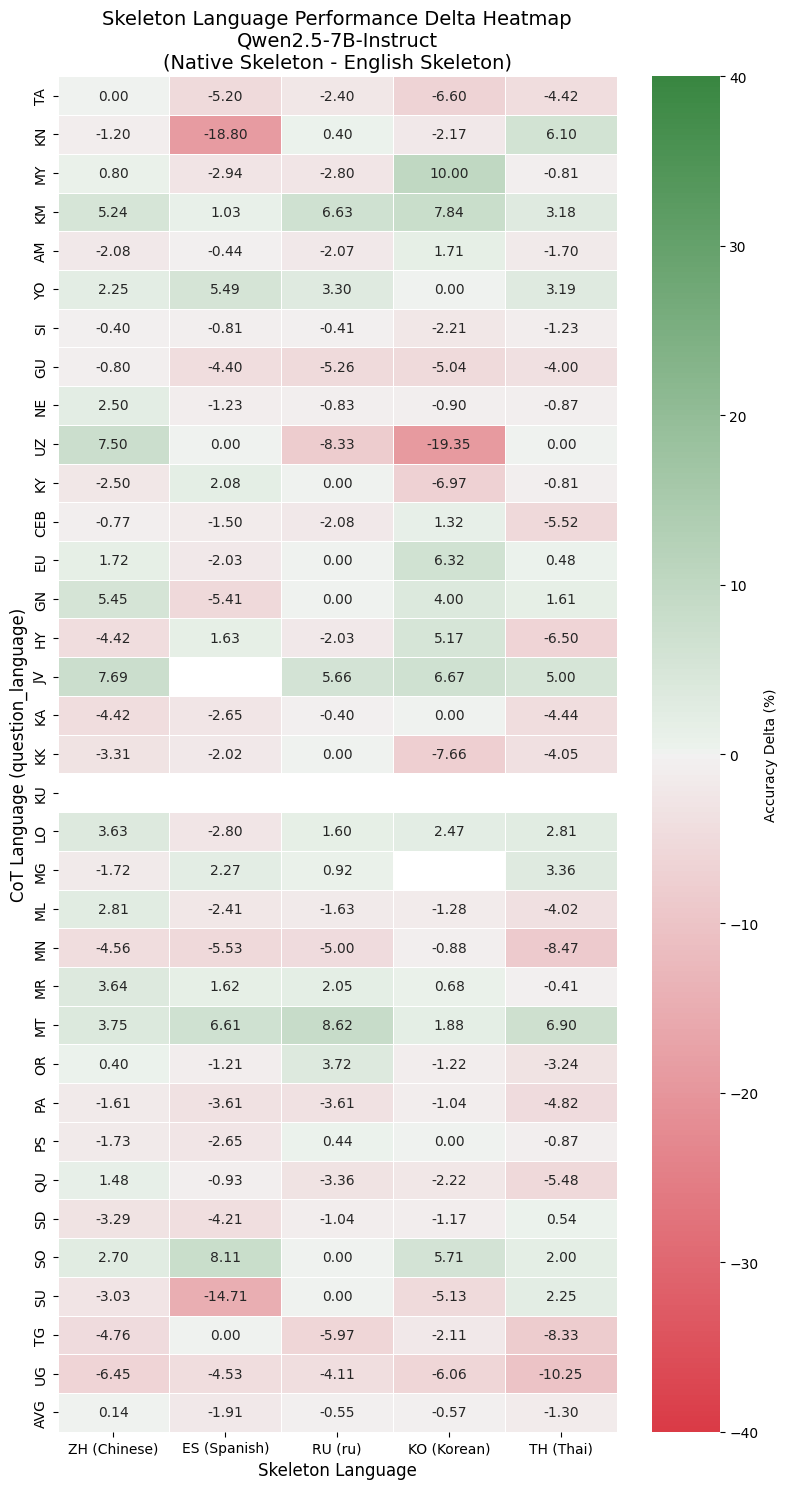

In [7]:
df = pd.DataFrame(index=COT_LANGUAGES, columns=SKELETON_LANGUAGES, dtype=float)
for skel_lang in SKELETON_LANGUAGES:
    for cot_lang in COT_LANGUAGES:
        if skel_lang in delta_matrix and cot_lang in delta_matrix[skel_lang]:
            df.loc[cot_lang, skel_lang] = delta_matrix[skel_lang][cot_lang]
        else:
            df.loc[cot_lang, skel_lang] = np.nan

x_labels = [f"{lang.upper()} ({LANGUAGE_NAMES.get(lang, lang)})" for lang in SKELETON_LANGUAGES]
y_labels = [f"{lang.upper()}" for lang in COT_LANGUAGES]

df.loc["AVG"] = df.mean(axis=0, skipna=True)
y_labels = [*y_labels, "AVG"]

plt.figure(figsize=(8, 15))
cmap = sns.diverging_palette(10, 130, as_cmap=True)

ax = sns.heatmap(
    df.astype(float),
    annot=True,
    fmt=".2f",
    cmap=cmap,
    center=0,
    vmin=-40,
    vmax=40,
    linewidths=0.5,
    xticklabels=x_labels,
    yticklabels=y_labels,
    cbar_kws={'label': 'Accuracy Delta (%)'}
)

plt.title(f"Skeleton Language Performance Delta Heatmap\n{MODEL}\n(Native Skeleton - English Skeleton)", fontsize=14)
plt.xlabel("Skeleton Language", fontsize=12)
plt.ylabel("CoT Language (question_language)", fontsize=12)

if TRANSLATED:
    SAVE_PATH = f"{PRJ_PATH}/figure/TransQ_skeleton_lang_delta_heatmap_{MODEL}.pdf"
else:
    SAVE_PATH = f"{PRJ_PATH}/figure/skeleton_lang_delta_heatmap_{MODEL}.pdf"
plt.tight_layout()
plt.savefig(SAVE_PATH, dpi=500, bbox_inches='tight')
print("✅ Heatmap saved to: skeleton_lang_delta_heatmap.png")
plt.show()


✅ Combined Heatmap saved to: /home/work/mlp/hslim/LASEF2/figure/skeleton_lang_delta_count_heatmap_Qwen2.5-7B-Instruct.pdf


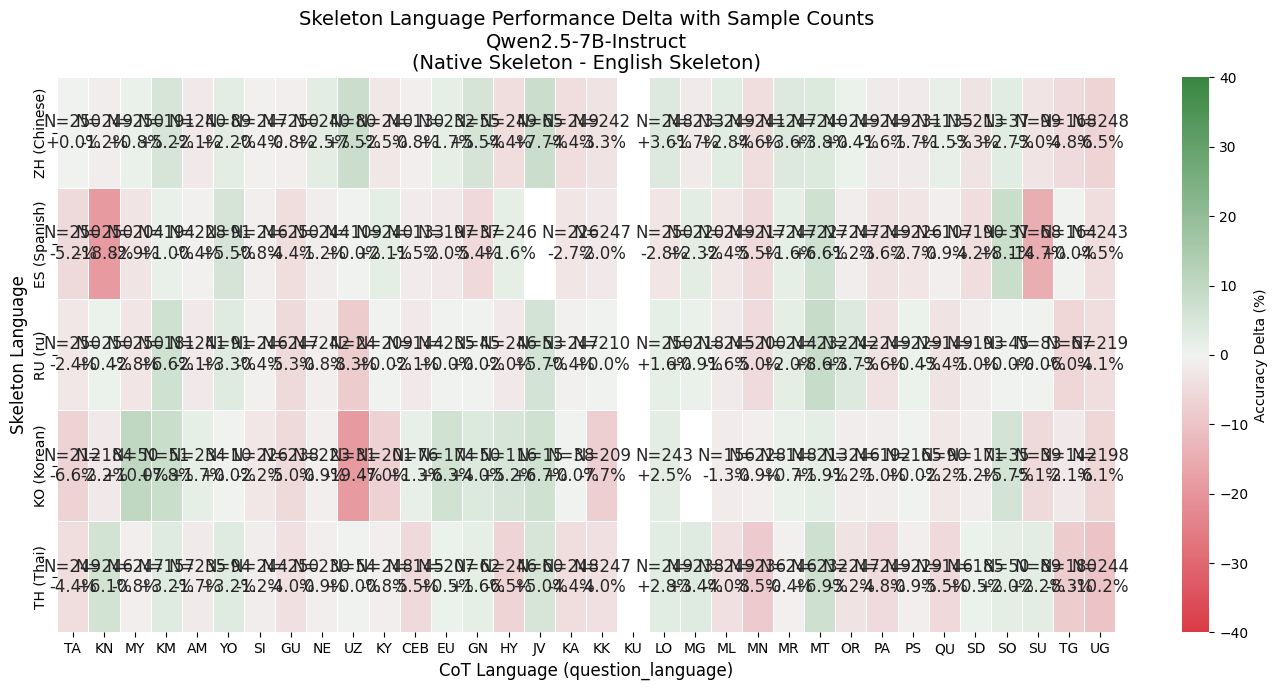

In [8]:
df_delta = pd.DataFrame(index=SKELETON_LANGUAGES, columns=COT_LANGUAGES, dtype=float)
df_count = pd.DataFrame(index=SKELETON_LANGUAGES, columns=COT_LANGUAGES, dtype=float)

for skel_lang in SKELETON_LANGUAGES:
    for cot_lang in COT_LANGUAGES:
        if skel_lang in delta_matrix and cot_lang in delta_matrix[skel_lang]:
            df_delta.loc[skel_lang, cot_lang] = delta_matrix[skel_lang][cot_lang]
            df_count.loc[skel_lang, cot_lang] = sample_counts[skel_lang][cot_lang]
        else:
            df_delta.loc[skel_lang, cot_lang] = np.nan
            df_count.loc[skel_lang, cot_lang] = np.nan

annot_combined = np.empty((len(SKELETON_LANGUAGES), len(COT_LANGUAGES)), dtype=object)
for i, skel_lang in enumerate(SKELETON_LANGUAGES):
    for j, cot_lang in enumerate(COT_LANGUAGES):
        delta_val = df_delta.loc[skel_lang, cot_lang]
        count_val = df_count.loc[skel_lang, cot_lang]
        if pd.notna(delta_val) and pd.notna(count_val):
            annot_combined[i, j] = f"N={int(count_val)}\n{delta_val:+.1f}%"
        else:
            annot_combined[i, j] = "N/A"

y_labels = [f"{lang.upper()} ({LANGUAGE_NAMES.get(lang, lang)})" for lang in SKELETON_LANGUAGES]
x_labels = [f"{lang.upper()}" for lang in COT_LANGUAGES]
plt.figure(figsize=(14, 7))
cmap = sns.diverging_palette(10, 130, as_cmap=True)

ax = sns.heatmap(
    df_delta.astype(float),
    annot=annot_combined,
    fmt="",
    cmap=cmap,
    center=0,
    vmin=-40,
    vmax=40,
    linewidths=0.5,
    xticklabels=x_labels,
    yticklabels=y_labels,
    cbar_kws={'label': 'Accuracy Delta (%)'},
    annot_kws={'fontsize': 12}
)

plt.title(f"Skeleton Language Performance Delta with Sample Counts\n{MODEL}\n(Native Skeleton - English Skeleton)", fontsize=14)
plt.xlabel("CoT Language (question_language)", fontsize=12)
plt.ylabel("Skeleton Language", fontsize=12)

if TRANSLATED:
    SAVE_PATH2 = f"{PRJ_PATH}/figure/TransQ_skeleton_lang_delta_count_heatmap_{MODEL}.pdf"
else:
    SAVE_PATH2 = f"{PRJ_PATH}/figure/skeleton_lang_delta_count_heatmap_{MODEL}.pdf"
plt.tight_layout()
plt.savefig(SAVE_PATH2, dpi=500, bbox_inches='tight')
print(f"✅ Combined Heatmap saved to: {SAVE_PATH2}")
plt.show()

✅ Combined Heatmap (Vertical) saved to: /home/work/mlp/hslim/LASEF2/figure/skeleton_lang_delta_count_heatmap_Qwen2.5-7B-Instruct.pdf


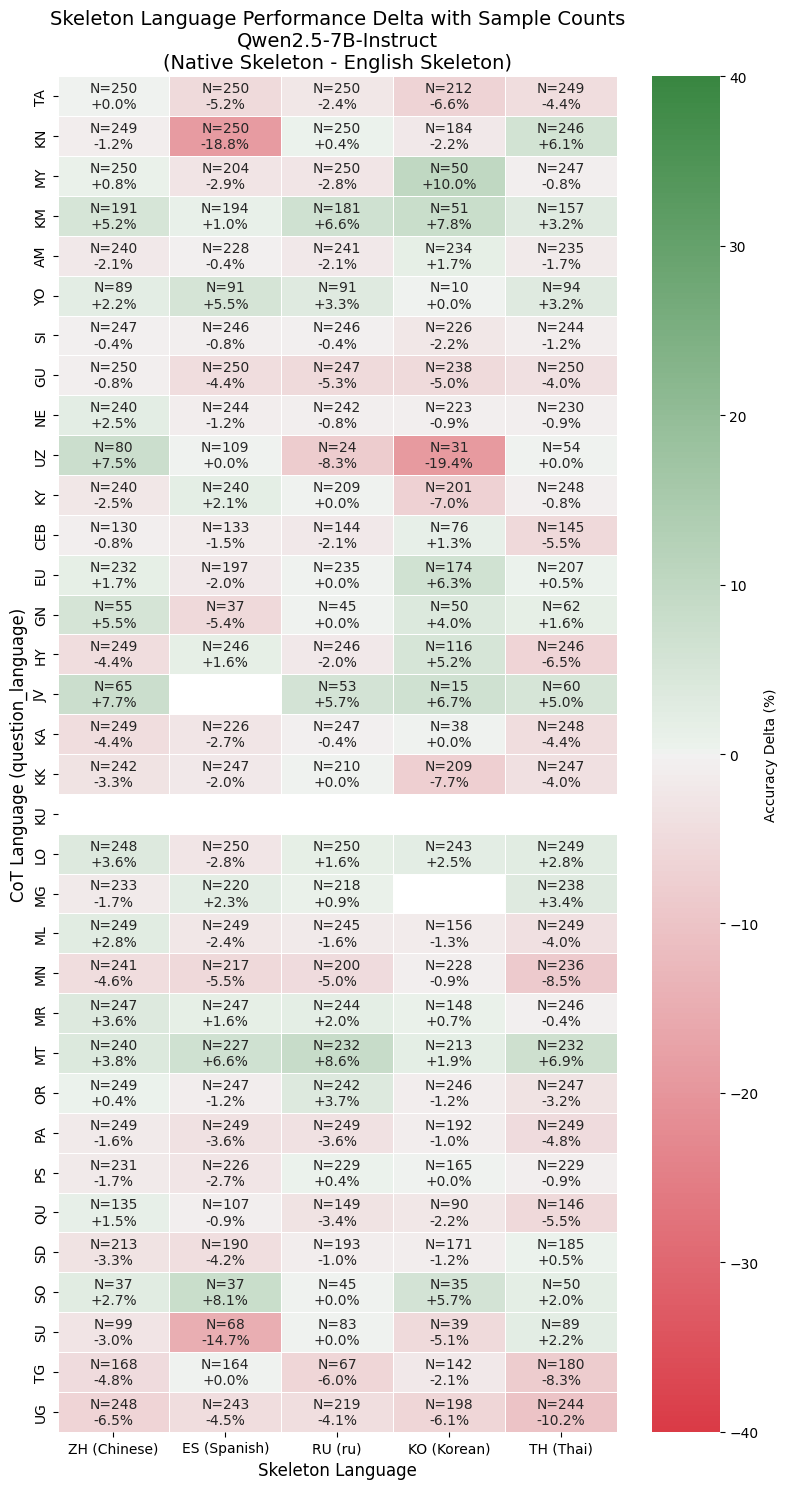

In [9]:
df_delta = pd.DataFrame(index=COT_LANGUAGES, columns=SKELETON_LANGUAGES, dtype=float)
df_count = pd.DataFrame(index=COT_LANGUAGES, columns=SKELETON_LANGUAGES, dtype=float)

for skel_lang in SKELETON_LANGUAGES:
    for cot_lang in COT_LANGUAGES:
        if skel_lang in delta_matrix and cot_lang in delta_matrix[skel_lang]:
            df_delta.loc[cot_lang, skel_lang] = delta_matrix[skel_lang][cot_lang]
            df_count.loc[cot_lang, skel_lang] = sample_counts[skel_lang][cot_lang]
        else:
            df_delta.loc[cot_lang, skel_lang] = np.nan
            df_count.loc[cot_lang, skel_lang] = np.nan

annot_combined = np.empty((len(COT_LANGUAGES), len(SKELETON_LANGUAGES)), dtype=object)
for i, cot_lang in enumerate(COT_LANGUAGES):
    for j, skel_lang in enumerate(SKELETON_LANGUAGES):
        delta_val = df_delta.loc[cot_lang, skel_lang]
        count_val = df_count.loc[cot_lang, skel_lang]
        if pd.notna(delta_val) and pd.notna(count_val):
            annot_combined[i, j] = f"N={int(count_val)}\n{delta_val:+.1f}%"
        else:
            annot_combined[i, j] = "N/A"

x_labels = [f"{lang.upper()} ({LANGUAGE_NAMES.get(lang, lang)})" for lang in SKELETON_LANGUAGES]
y_labels = [f"{lang.upper()}" for lang in COT_LANGUAGES]


plt.figure(figsize=(8, 15))
cmap = sns.diverging_palette(10, 130, as_cmap=True)

ax = sns.heatmap(
    df_delta.astype(float),
    annot=annot_combined,
    fmt="",
    cmap=cmap,
    center=0,
    vmin=-40,
    vmax=40,
    linewidths=0.5,
    xticklabels=x_labels,
    yticklabels=y_labels,
    cbar_kws={'label': 'Accuracy Delta (%)'},
    annot_kws={'fontsize': 10} 
)

plt.title(f"Skeleton Language Performance Delta with Sample Counts\n{MODEL}\n(Native Skeleton - English Skeleton)", fontsize=14)
plt.xlabel("Skeleton Language", fontsize=12)
plt.ylabel("CoT Language (question_language)", fontsize=12)

if TRANSLATED:
    SAVE_PATH2 = f"{PRJ_PATH}/figure/TransQ_skeleton_lang_delta_count_heatmap_{MODEL}.pdf"
else:
    SAVE_PATH2 = f"{PRJ_PATH}/figure/skeleton_lang_delta_count_heatmap_{MODEL}.pdf"
plt.tight_layout()
plt.savefig(SAVE_PATH2, dpi=500, bbox_inches='tight')
print(f"✅ Combined Heatmap (Vertical) saved to: {SAVE_PATH2}")
plt.show()

In [10]:
SAVE_DIR = f"{PRJ_PATH}/dataframe"

if TRANSLATED:
    delta_path = f"{SAVE_DIR}/TransQ_df_delta_{MODEL}.csv"
    count_path = f"{SAVE_DIR}/TransQ_df_count_{MODEL}.csv"
else:
    delta_path = f"{SAVE_DIR}/df_delta_{MODEL}.csv"
    count_path = f"{SAVE_DIR}/df_count_{MODEL}.csv"

df_delta.to_csv(delta_path, index=True)
df_count.to_csv(count_path, index=True)

print("✔ df_delta / df_count CSV 저장 완료")


✔ df_delta / df_count CSV 저장 완료


In [11]:
# ========================================
# 통계 검증 (Bootstrap + Permutation + McNemar + FDR + Sign Test)
# ========================================
import numpy as np
import pandas as pd
from statsmodels.stats.multitest import multipletests
from statsmodels.stats.contingency_tables import mcnemar
from scipy.stats import binomtest

N_BOOTSTRAP = 10000
N_PERMUTATION = 10000
ALPHA = 0.05
SEED = 42


def paired_bootstrap_ci(en_arr, target_arr, n_boot=N_BOOTSTRAP, alpha=ALPHA, seed=SEED):
    rng = np.random.default_rng(seed)
    n = len(en_arr)
    observed = (target_arr.mean() - en_arr.mean()) * 100
    idx_mat = rng.integers(0, n, size=(n_boot, n))
    deltas = (target_arr[idx_mat].mean(axis=1) - en_arr[idx_mat].mean(axis=1)) * 100
    lo = float(np.percentile(deltas, alpha / 2 * 100))
    hi = float(np.percentile(deltas, (1 - alpha / 2) * 100))
    p = 2 * np.mean(deltas <= 0) if observed > 0 else 2 * np.mean(deltas >= 0)
    return observed, lo, hi, min(float(p), 1.0)


def paired_permutation_test(en_arr, target_arr, n_perm=N_PERMUTATION, seed=SEED):
    rng = np.random.default_rng(seed)
    n = len(en_arr)
    observed = (target_arr.mean() - en_arr.mean()) * 100
    swap = rng.random((n_perm, n)) < 0.5
    en_p = np.where(swap, target_arr[None, :], en_arr[None, :])
    target_p = np.where(swap, en_arr[None, :], target_arr[None, :])
    deltas = (target_p.mean(axis=1) - en_p.mean(axis=1)) * 100
    p = (np.sum(np.abs(deltas) >= abs(observed)) + 1) / (n_perm + 1)
    return observed, float(p)


def mcnemar_test_binary(en_arr, target_arr):
    en_bin = (en_arr >= 0.5).astype(int)
    tg_bin = (target_arr >= 0.5).astype(int)
    b = int(np.sum((en_bin == 1) & (tg_bin == 0)))
    c = int(np.sum((en_bin == 0) & (tg_bin == 1)))
    if b + c == 0:
        return 1.0, b, c
    table = np.array([[0, b], [c, 0]])
    res = mcnemar(table, exact=(b + c) < 25, correction=True)
    return float(res.pvalue), b, c


# Run tests for every cell
rows = []
metric = 'strict'
for cot, skel_dict in per_sample_results_dict.items():
    for skel, data in skel_dict.items():
        en_arr = data[f'{metric}_en']
        target_arr = data[f'{metric}_target']
        if len(en_arr) < 10:
            continue
        delta, lo, hi, boot_p = paired_bootstrap_ci(en_arr, target_arr)
        _, perm_p = paired_permutation_test(en_arr, target_arr)
        mc_p, b, c = mcnemar_test_binary(en_arr, target_arr)
        rows.append({
            'cot_lang': cot, 'skel_lang': skel, 'n': len(en_arr),
            'delta': delta, 'ci_lower': lo, 'ci_upper': hi,
            'boot_p': boot_p, 'perm_p': perm_p, 'mcnemar_p': mc_p,
            'discordant_total': b + c,
        })

stats_df = pd.DataFrame(rows)

# FDR correction
for col in ['boot_p', 'perm_p', 'mcnemar_p']:
    reject, p_adj, _, _ = multipletests(stats_df[col].values, alpha=ALPHA, method='fdr_bh')
    stats_df[f'{col}_fdr'] = p_adj
    stats_df[f'sig_fdr_{col}'] = reject

# Aggregate sign test per skeleton
agg_rows = []
for skel in SKELETON_LANGUAGES:
    sub = stats_df[stats_df['skel_lang'] == skel]
    n_neg = int((sub['delta'] < 0).sum())
    n_pos = int((sub['delta'] > 0).sum())
    n_eff = n_neg + n_pos
    p = binomtest(n_neg, n_eff, p=0.5, alternative='two-sided').pvalue if n_eff > 0 else 1.0
    agg_rows.append({
        'skel_lang': skel, 'n_total': len(sub),
        'n_negative': n_neg, 'n_positive': n_pos,
        'mean_delta': float(sub['delta'].mean()),
        'sign_test_p': float(p),
    })
agg_df = pd.DataFrame(agg_rows)

# Save
suffix = "TransQ_" if TRANSLATED else ""
rollout_tag = f"_rollout{ROLLOUT_COUNT}" if ROLLOUT else ""
stats_df.to_csv(f"{SAVE_DIR}/{suffix}stats_{metric}_{MODEL}{rollout_tag}.csv", index=False)
agg_df.to_csv(f"{SAVE_DIR}/{suffix}aggregate_sign_{MODEL}{rollout_tag}.csv", index=False)

# Summary
print("="*70)
print(f"STATISTICAL VALIDATION ({metric} metric, n={len(stats_df)} cells)")
print("="*70)
for col, label in [('boot_p', 'Bootstrap'), ('perm_p', 'Permutation'), ('mcnemar_p', 'McNemar')]:
    raw = int((stats_df[col] < ALPHA).sum())
    fdr = int(stats_df[f'sig_fdr_{col}'].sum())
    sig = stats_df[stats_df[f'sig_fdr_{col}']]
    pos_sig = int((sig['delta'] > 0).sum())
    neg_sig = int((sig['delta'] < 0).sum())
    print(f"  {label:12s}  Raw p<.05: {raw:3d}/{len(stats_df)}  |  FDR-sig: {fdr:3d}  |  (+{pos_sig}, -{neg_sig})")

print()
print("Top POSITIVE FDR-sig cells (permutation):")
pos = stats_df[stats_df['sig_fdr_perm_p'] & (stats_df['delta'] > 0)].nlargest(10, 'delta')
if len(pos) > 0:
    for _, r in pos.iterrows():
        print(f"  {r['cot_lang']:>3}-{r['skel_lang']:<3}  Δ={r['delta']:+6.2f}  CI=[{r['ci_lower']:+6.2f},{r['ci_upper']:+6.2f}]  p_fdr={r['perm_p_fdr']:.4f}")
else:
    print("  (none)")

print()
print("="*70)
print("AGGREGATE SIGN TEST (per skeleton language)")
print("="*70)
print(agg_df.to_string(index=False))

print()
print(f"Median discordant pairs per cell: {stats_df['discordant_total'].median():.0f}")
print(f"Cells with discordant < 20: {(stats_df['discordant_total'] < 20).sum()}")


STATISTICAL VALIDATION (strict metric, n=163 cells)
  Bootstrap     Raw p<.05:  15/163  |  FDR-sig:   2  |  (+1, -1)
  Permutation   Raw p<.05:  10/163  |  FDR-sig:   1  |  (+0, -1)
  McNemar       Raw p<.05:  10/163  |  FDR-sig:   1  |  (+0, -1)

Top POSITIVE FDR-sig cells (permutation):
  (none)

AGGREGATE SIGN TEST (per skeleton language)
skel_lang  n_total  n_negative  n_positive  mean_delta  sign_test_p
       zh       33          17          15    0.136998     0.860050
       es       32          22           8   -1.912478     0.016125
       ru       33          17          10   -0.545871     0.247789
       ko       32          17          12   -0.570373     0.458258
       th       33          20          12   -1.297004     0.215327

Median discordant pairs per cell: 40
Cells with discordant < 20: 41


✅ Significance heatmap saved: /home/work/mlp/hslim/LASEF2/figure/skeleton_delta_heatmap_sig_Qwen2.5-7B-Instruct.pdf


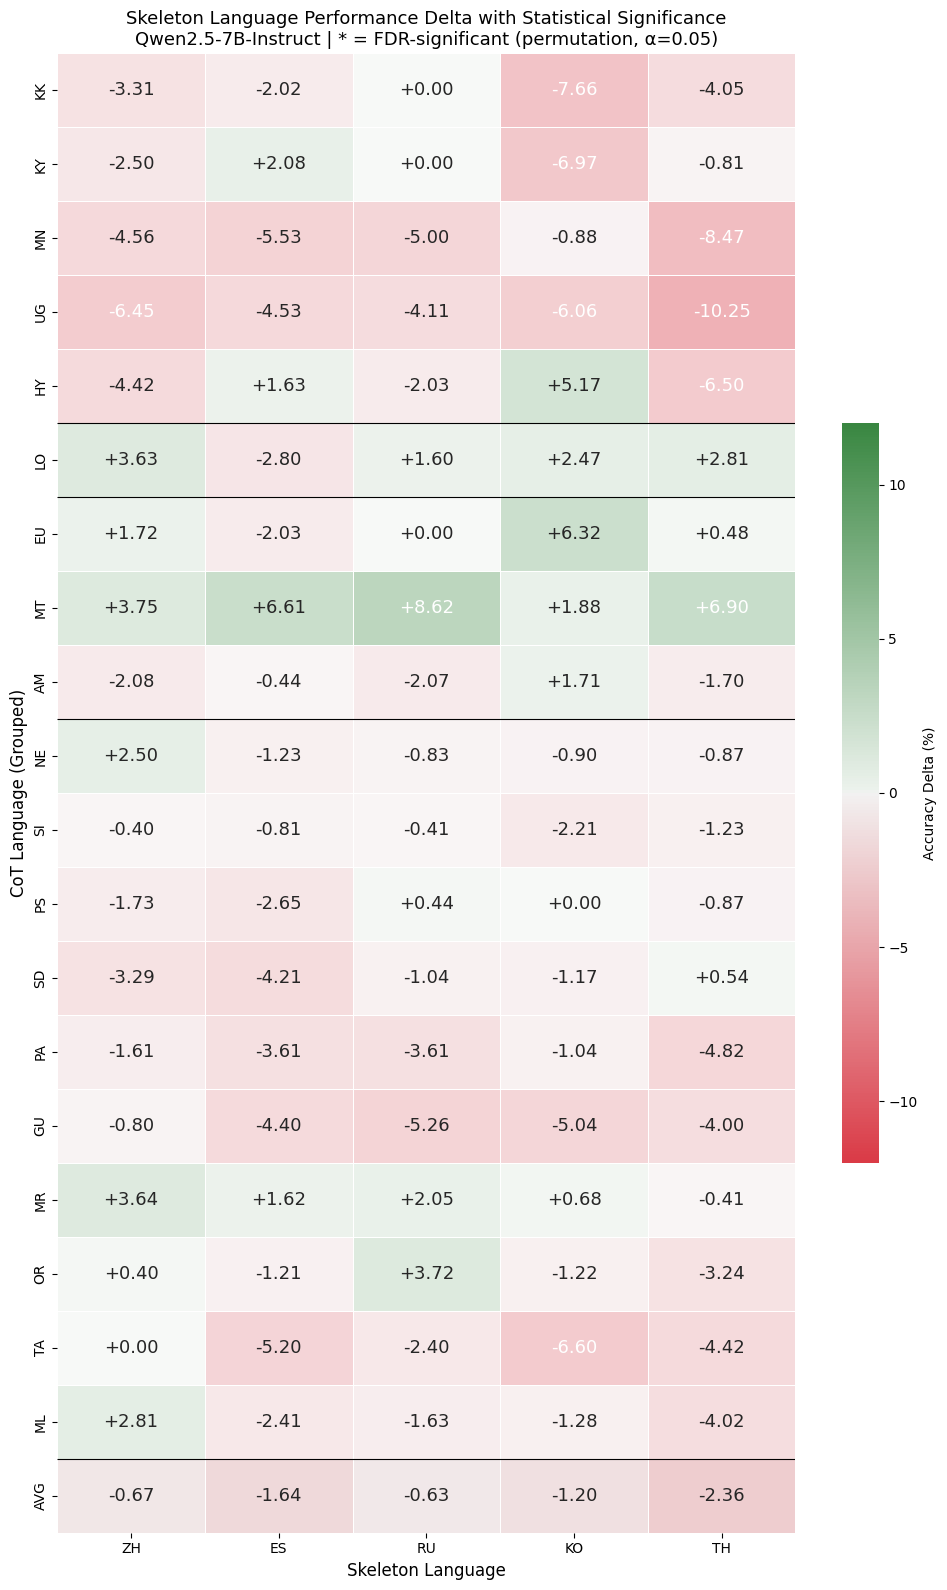

In [12]:
# ========================================
# 유의성 표시된 Heatmap
# ========================================
import seaborn as sns
import matplotlib.pyplot as plt
import os

EXCLUDE_LANGS = ["kn",'ku', 'jv', 'mg', 'so', 'gn', 'uz', 'su', 'yo', 'qu', 'ceb', 'ka', 'tg', 'my', 'km']
SORT_ORDER_GROUPS = {
    "Cyrillic/Post-Soviet": ['kk', 'ky', 'mn', 'ug', 'hy'],
    "SE Asia (Thai/Pali)": ['lo', 'km', 'my'],
    "Euro/Misc": ['eu', 'mt', 'am'],
    "Indo-Subcontinent": ['ne', 'si', 'ps', 'sd', 'pa', 'gu', 'mr', 'or', 'ta', 'ml']
}

plot_df = stats_df[~stats_df['cot_lang'].isin(EXCLUDE_LANGS)].copy()
desired = sum(SORT_ORDER_GROUPS.values(), [])
ordered_cot = [l for l in desired if l in plot_df['cot_lang'].unique()]
ordered_cot += [l for l in plot_df['cot_lang'].unique() if l not in ordered_cot]

delta_mat = pd.DataFrame(index=ordered_cot, columns=SKELETON_LANGUAGES, dtype=float)
sig_mat = pd.DataFrame(index=ordered_cot, columns=SKELETON_LANGUAGES, dtype=bool)
for _, r in plot_df.iterrows():
    delta_mat.loc[r['cot_lang'], r['skel_lang']] = r['delta']
    sig_mat.loc[r['cot_lang'], r['skel_lang']] = bool(r['sig_fdr_perm_p'])

delta_mat.loc['AVG'] = delta_mat.mean(axis=0, skipna=True)
sig_mat.loc['AVG'] = False

annot = pd.DataFrame(index=delta_mat.index, columns=delta_mat.columns, dtype=object)
for r in delta_mat.index:
    for c in delta_mat.columns:
        v = delta_mat.loc[r, c]
        if pd.isna(v):
            annot.loc[r, c] = ""
        elif sig_mat.loc[r, c]:
            annot.loc[r, c] = f"{v:+.2f}*"
        else:
            annot.loc[r, c] = f"{v:+.2f}"

fig, ax = plt.subplots(figsize=(10, 16))
cmap = sns.diverging_palette(10, 130, as_cmap=True)
sns.heatmap(delta_mat.astype(float), annot=annot.values, fmt='',
            annot_kws={"size": 13}, cmap=cmap, center=0, vmin=-12, vmax=12,
            linewidths=0.5, xticklabels=[s.upper() for s in SKELETON_LANGUAGES],
            yticklabels=[r.upper() for r in delta_mat.index],
            cbar_kws={'label': 'Accuracy Delta (%)', 'shrink': 0.5}, ax=ax)

for i, r in enumerate(delta_mat.index):
    for j, c in enumerate(delta_mat.columns):
        if r == 'AVG': continue
        if not sig_mat.loc[r, c]:
            ax.add_patch(plt.Rectangle((j, i), 1, 1, fill=True,
                                       facecolor='white', alpha=0.55,
                                       edgecolor='none'))

current_idx = 0
for group_name, langs in SORT_ORDER_GROUPS.items():
    count = sum(1 for l in langs if l in delta_mat.index)
    if count > 0:
        current_idx += count
        ax.hlines(current_idx, *ax.get_xlim(), colors='black', linewidth=0.8)

plt.title(f"Skeleton Language Performance Delta with Statistical Significance\n"
          f"{MODEL} | * = FDR-significant (permutation, α={ALPHA})", fontsize=13)
plt.xlabel("Skeleton Language", fontsize=12)
plt.ylabel("CoT Language (Grouped)", fontsize=12)
plt.tight_layout()

os.makedirs(f"{PRJ_PATH}/figure", exist_ok=True)
heatmap_path = f"{PRJ_PATH}/figure/skeleton_delta_heatmap_sig_{MODEL}.pdf"
plt.savefig(heatmap_path, dpi=500, bbox_inches='tight')
print(f"✅ Significance heatmap saved: {heatmap_path}")
plt.show()


## load csv

Original Count: 34, Filtered Count: 34
Excluded: []
✅ Heatmap saved to: /home/work/mlp/hslim/LASEF2/figure/skeleton_lang_delta_heatmap_Qwen2.5-7B-Instruct.pdf


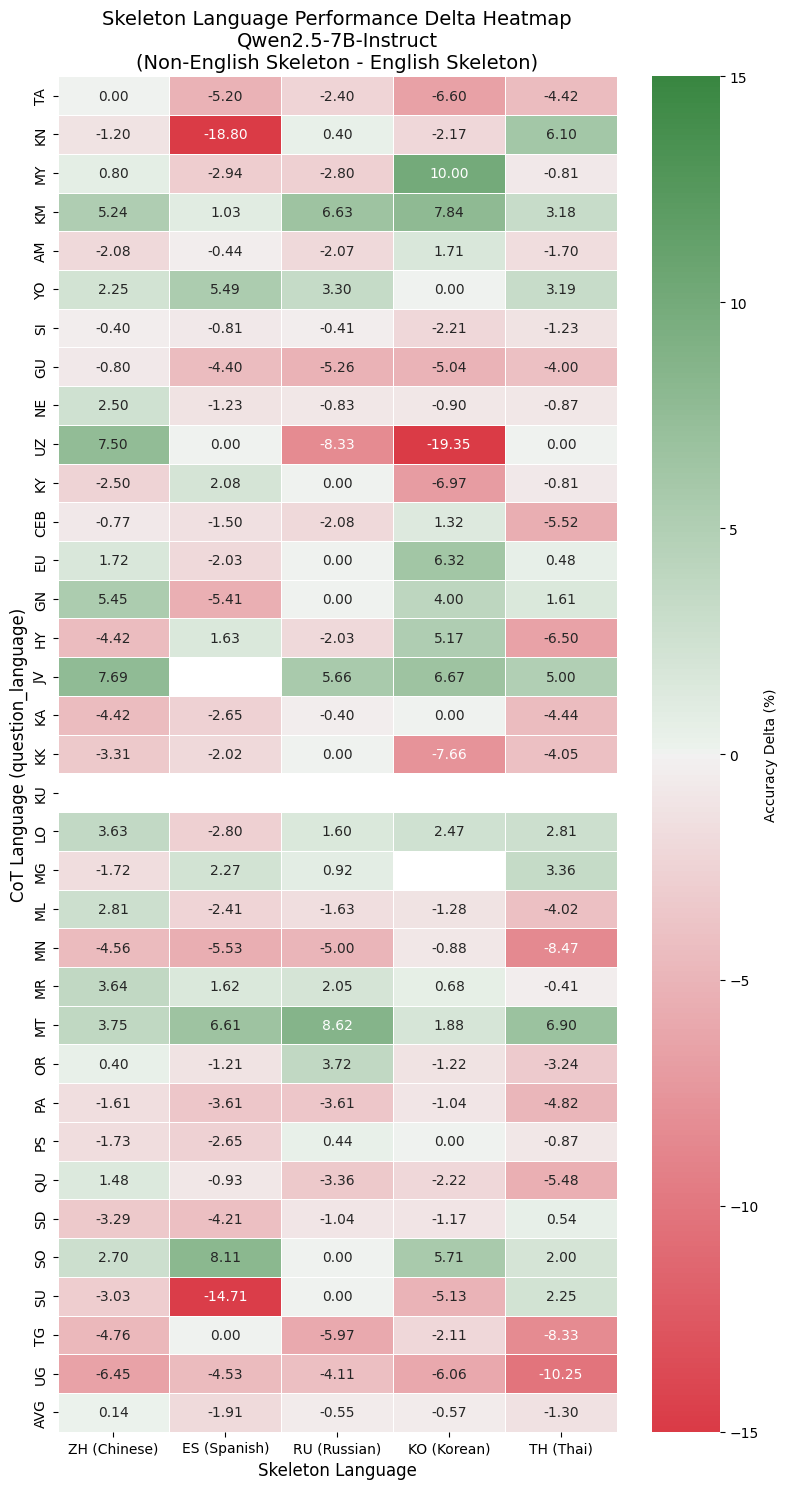

In [13]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

TRANSLATED = False
EXCLUDE_LANGS = ["kn",'ku', 'jv', 'mg', 'so', 'gn', 'uz', 'su', 'yo', 'qu', 'ceb', 'ka', 'tg', 'my', 'km']
EXCLUDE_LANGS = []

LANGUAGE_NAMES = {
        "ta": "Tamil", "kn": "Kannada", "my": "Burmese",
        "km": "Khmer", "am": "Amharic", "yo": "Yoruba",
        "si": "Sinhala", "gu": "Gujarati", "ne": "Nepali",
        "uz": "Uzbek", "ky": "Kyrgyz",
        "ceb": "Cebuano", "eu": "Basque", "gn": "Guarani",
        "hy": "Armenian", "jv": "Javanese", "ka": "Georgian",
        "kk": "Kazakh", "ku": "Kurdish", "lo": "Lao",
        "mg": "Malagasy", "ml": "Malayalam", "mn": "Mongolian",
        "mr": "Marathi", "mt": "Maltese", "or": "Odia",
        "pa": "Punjabi", "ps": "Pashto", "qu": "Quechua",
        "sd": "Sindhi", "so": "Somali", "su": "Sundanese",
        "tg": "Tajik", "ug": "Uyghur",
        "en": "English", "zh": "Chinese", "es": "Spanish", "ru": "Russian",
        "ko": "Korean", "th": "Thai", "sw": "Swahili", "te": "Telugu",
    }
SKELETON_LANGUAGES = ["zh", "es", "ru", "ko", "th"]


if TRANSLATED:
    data_path = f"{PRJ_PATH}/dataframe/TransQ_df_delta_{MODEL}.csv"
else:
    data_path = f"{PRJ_PATH}/dataframe/df_delta_{MODEL}.csv"
df_raw = pd.read_csv(data_path, index_col=0)

delta_matrix = df_raw.drop(index=EXCLUDE_LANGS, errors='ignore')

COT_LANGUAGES = delta_matrix.index.tolist()

SKELETON_LANGUAGES = [lang for lang in SKELETON_LANGUAGES if lang not in EXCLUDE_LANGS]

print(f"Original Count: {len(df_raw)}, Filtered Count: {len(delta_matrix)}")
print(f"Excluded: {EXCLUDE_LANGS}")


df = pd.DataFrame(index=COT_LANGUAGES, columns=SKELETON_LANGUAGES, dtype=float)

for skel_lang in SKELETON_LANGUAGES:
    for cot_lang in COT_LANGUAGES:
        if skel_lang in delta_matrix and cot_lang in delta_matrix[skel_lang]:
            df.loc[cot_lang, skel_lang] = delta_matrix[skel_lang][cot_lang]
        else:
            df.loc[cot_lang, skel_lang] = np.nan

x_labels = [f"{lang.upper()} ({LANGUAGE_NAMES.get(lang, lang)})" for lang in SKELETON_LANGUAGES]
y_labels = [f"{lang.upper()}" for lang in COT_LANGUAGES]

df.loc["AVG"] = df.mean(axis=0, skipna=True)
y_labels = [*y_labels, "AVG"]

plt.figure(figsize=(8, 15))
cmap = sns.diverging_palette(10, 130, as_cmap=True)

ax = sns.heatmap(
    df.astype(float),
    annot=True,
    fmt=".2f",
    cmap=cmap,
    center=0,
    vmin=-15,
    vmax=15,
    linewidths=0.5,
    xticklabels=x_labels,
    yticklabels=y_labels,
    cbar_kws={'label': 'Accuracy Delta (%)'}
)

plt.title(f"Skeleton Language Performance Delta Heatmap\n{MODEL}\n(Non-English Skeleton - English Skeleton)", fontsize=14)
plt.xlabel("Skeleton Language", fontsize=12)
plt.ylabel("CoT Language (question_language)", fontsize=12)

if TRANSLATED:
    SAVE_PATH = f"{PRJ_PATH}/figure/TransQ_skeleton_lang_delta_heatmap_{MODEL}.pdf"
else:
    SAVE_PATH = f"{PRJ_PATH}/figure/skeleton_lang_delta_heatmap_{MODEL}.pdf"

plt.tight_layout()
plt.savefig(SAVE_PATH, dpi=500, bbox_inches='tight')
print(f"✅ Heatmap saved to: {SAVE_PATH}")
plt.show()

Original Shape: (34, 5)
Filtered Shape: (19, 5)
Excluded: ['kn', 'ku', 'jv', 'mg', 'so', 'gn', 'uz', 'su', 'yo', 'qu', 'ceb', 'ka', 'tg', 'my', 'km']
✅ Combined Heatmap (Vertical) saved to: /home/work/mlp/hslim/LASEF2/figure/skeleton_lang_delta_count_heatmap_Qwen2.5-7B-Instruct.pdf


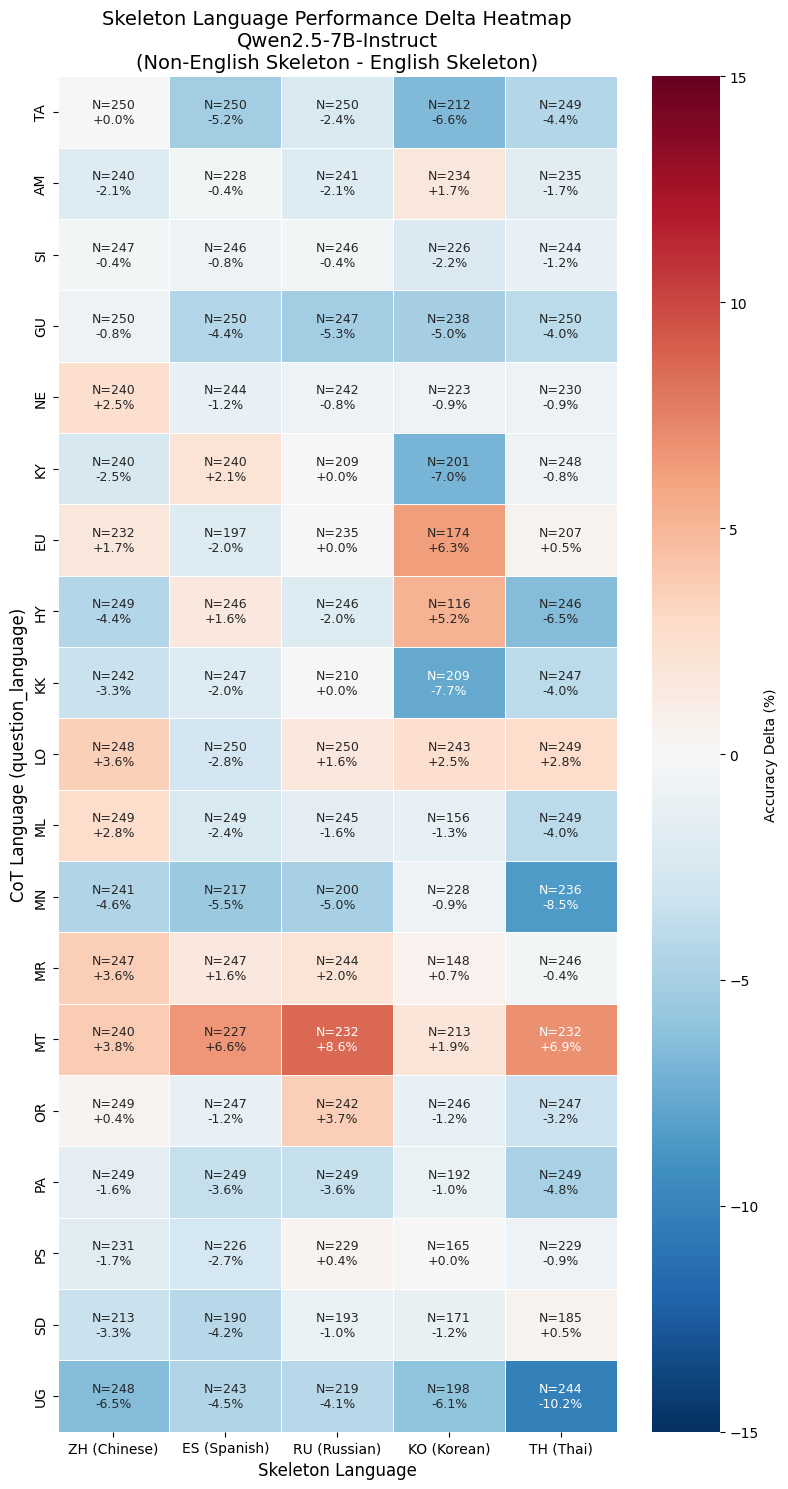

In [14]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

TRANSLATED = False
MODEL = "Qwen2.5-7B-Instruct"

if TRANSLATED:
    delta_file_path = f"{PRJ_PATH}/dataframe/TransQ_df_delta_{MODEL}.csv" 
    count_file_path = f"{PRJ_PATH}/dataframe/TransQ_df_count_{MODEL}.csv"
else:
    delta_file_path = f"{PRJ_PATH}/dataframe/df_delta_{MODEL}.csv" 
    count_file_path = f"{PRJ_PATH}/dataframe/df_count_{MODEL}.csv"
df_delta = pd.read_csv(delta_file_path, index_col=0)
df_count = pd.read_csv(count_file_path, index_col=0)

EXCLUDE_LANGS = ["kn",'ku', 'jv', 'mg', 'so', 'gn', 'uz', 'su', 'yo', 'qu', 'ceb', 'ka', 'tg', 'my', 'km']


print(f"Original Shape: {df_delta.shape}")

df_delta = df_delta.drop(index=EXCLUDE_LANGS, errors='ignore')
df_count = df_count.drop(index=EXCLUDE_LANGS, errors='ignore')

COT_LANGUAGES = df_delta.index.tolist()
SKELETON_LANGUAGES = df_delta.columns.tolist()

print(f"Filtered Shape: {df_delta.shape}")
print(f"Excluded: {EXCLUDE_LANGS}")

annot_combined = np.empty((len(COT_LANGUAGES), len(SKELETON_LANGUAGES)), dtype=object)

for i, cot_lang in enumerate(COT_LANGUAGES):
    for j, skel_lang in enumerate(SKELETON_LANGUAGES):
        delta_val = df_delta.loc[cot_lang, skel_lang]
        count_val = df_count.loc[cot_lang, skel_lang]
        
        if pd.notna(delta_val) and pd.notna(count_val):
            annot_combined[i, j] = f"N={int(count_val)}\n{delta_val:+.1f}%"
        else:
            annot_combined[i, j] = "N/A"

x_labels = [f"{lang.upper()} ({LANGUAGE_NAMES.get(lang, lang)})" if 'LANGUAGE_NAMES' in globals() else lang.upper() for lang in SKELETON_LANGUAGES]
y_labels = [f"{lang.upper()}" for lang in COT_LANGUAGES]

plt.figure(figsize=(8, 15))
cmap = plt.get_cmap("RdBu_r")


ax = sns.heatmap(
    df_delta.astype(float),
    annot=annot_combined,
    fmt="",   
    cmap=cmap,
    center=0,
    vmin=-15,
    vmax=15,
    linewidths=0.5,
    xticklabels=x_labels,
    yticklabels=y_labels,
    cbar_kws={'label': 'Accuracy Delta (%)'},
    annot_kws={'fontsize': 9}
)

plt.title(f"Skeleton Language Performance Delta Heatmap\n{MODEL}\n(Non-English Skeleton - English Skeleton)", fontsize=14)
plt.xlabel("Skeleton Language", fontsize=12)
plt.ylabel("CoT Language (question_language)", fontsize=12)

# 저장 경로 설정
if 'TRANSLATED' in globals() and TRANSLATED:
    SAVE_PATH2 = f"{PRJ_PATH}/figure/TransQ_skeleton_lang_delta_count_heatmap_{MODEL}.pdf"
else:
    SAVE_PATH2 = f"{PRJ_PATH}/figure/skeleton_lang_delta_count_heatmap_{MODEL}.pdf"

plt.tight_layout()
plt.savefig(SAVE_PATH2, dpi=500, bbox_inches='tight')
print(f"✅ Combined Heatmap (Vertical) saved to: {SAVE_PATH2}")
plt.show()

Sorted COT Languages: ['kk', 'ky', 'mn', 'ug', 'hy', 'lo', 'eu', 'mt', 'am', 'ne', 'si', 'ps', 'sd', 'pa', 'gu', 'mr', 'or', 'ta', 'ml']
✅ Sorted Heatmap saved to: /home/work/mlp/hslim/LASEF2/figure/skeleton_lang_delta_heatmap_sorted_Qwen2.5-7B-Instruct.pdf


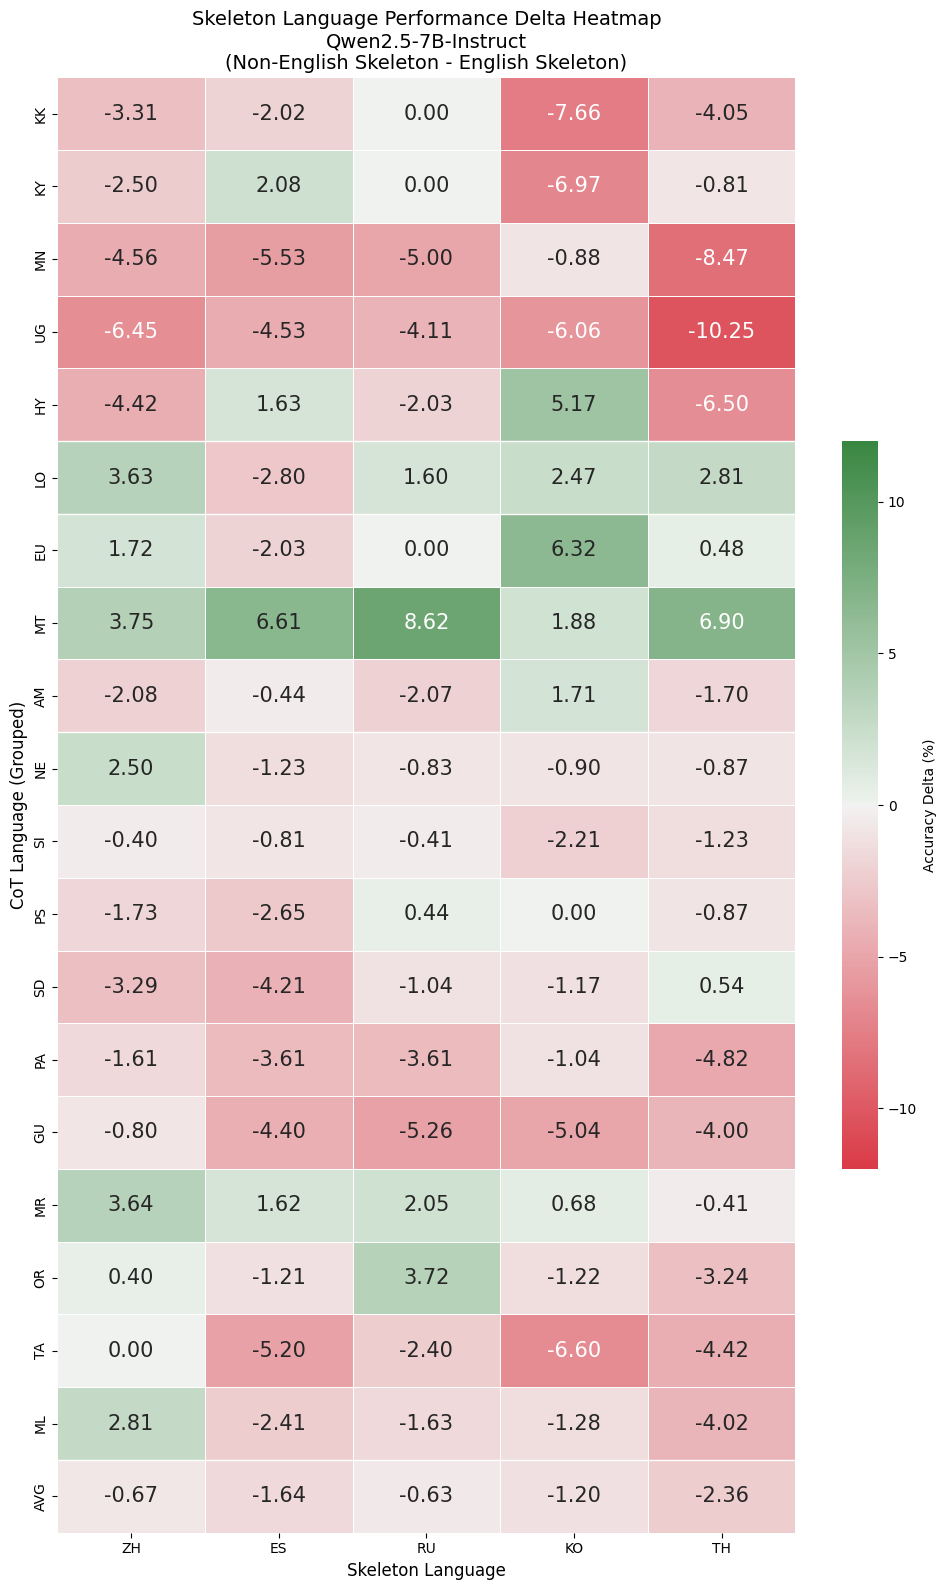

In [15]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

TRANSLATED = False

EXCLUDE_LANGS = ["kn",'ku', 'jv', 'mg', 'so', 'gn', 'uz', 'su', 'yo', 'qu', 'ceb', 'ka', 'tg', 'my', 'km']

LANGUAGE_NAMES = {
        "ta": "Tamil", "kn": "Kannada", "my": "Burmese",
        "km": "Khmer", "am": "Amharic", "yo": "Yoruba",
        "si": "Sinhala", "gu": "Gujarati", "ne": "Nepali",
        "uz": "Uzbek", "ky": "Kyrgyz",
        "ceb": "Cebuano", "eu": "Basque", "gn": "Guarani",
        "hy": "Armenian", "jv": "Javanese", "ka": "Georgian",
        "kk": "Kazakh", "ku": "Kurdish", "lo": "Lao",
        "mg": "Malagasy", "ml": "Malayalam", "mn": "Mongolian",
        "mr": "Marathi", "mt": "Maltese", "or": "Odia",
        "pa": "Punjabi", "ps": "Pashto", "qu": "Quechua",
        "sd": "Sindhi", "so": "Somali", "su": "Sundanese",
        "tg": "Tajik", "ug": "Uyghur"
    }


if TRANSLATED:
    data_path = f"{PRJ_PATH}/dataframe/TransQ_df_delta_{MODEL}.csv"
else:
    data_path = f"{PRJ_PATH}/dataframe/df_delta_{MODEL}.csv"
df_raw = pd.read_csv(data_path, index_col=0)

SORT_ORDER_GROUPS = {
    "Cyrillic/Post-Soviet": ['kk', 'ky', 'mn', 'ug', 'hy'], 
    
    "SE Asia (Thai/Pali)": ['lo', 'km', 'my'],
    
    "Euro/Misc": ['eu', 'mt', 'am'],
    
    "Indo-Subcontinent": ['ne', 'si', 'ps', 'sd', 'pa', 'gu', 'mr', 'or', 'ta', 'ml']
}

DESIRED_ORDER = []
for group in SORT_ORDER_GROUPS.values():
    DESIRED_ORDER.extend(group)

delta_matrix = df_raw.drop(index=EXCLUDE_LANGS, errors='ignore')

available_langs = delta_matrix.index.tolist()

sorted_langs = [lang for lang in DESIRED_ORDER if lang in available_langs]

remaining_langs = [lang for lang in available_langs if lang not in sorted_langs]

FINAL_COT_ORDER = sorted_langs + remaining_langs
COT_LANGUAGES = FINAL_COT_ORDER  

print(f"Sorted COT Languages: {COT_LANGUAGES}")

df = pd.DataFrame(index=COT_LANGUAGES, columns=SKELETON_LANGUAGES, dtype=float)

for skel_lang in SKELETON_LANGUAGES:
    for cot_lang in COT_LANGUAGES:
        if skel_lang in delta_matrix and cot_lang in delta_matrix[skel_lang]:
             try:
                df.loc[cot_lang, skel_lang] = delta_matrix.loc[cot_lang, skel_lang]
             except:
                df.loc[cot_lang, skel_lang] = delta_matrix[skel_lang][cot_lang]
        else:
            df.loc[cot_lang, skel_lang] = np.nan

x_labels = [f"{lang.upper()}" for lang in SKELETON_LANGUAGES]
y_labels = [f"{lang.upper()}" for lang in COT_LANGUAGES]

df.loc["AVG"] = df.mean(axis=0, skipna=True)
y_labels_final = [*y_labels, "AVG"]

plt.figure(figsize=(10, 16))
cmap = sns.diverging_palette(10, 130, as_cmap=True)

ax = sns.heatmap(
    df.astype(float),
    annot=True,
    fmt=".2f",
    annot_kws={"size": 15}, 
    cmap=cmap,
    center=0,
    vmin=-12,
    vmax=12,
    linewidths=0.5,
    xticklabels=x_labels,
    yticklabels=y_labels_final,
    cbar_kws={'label': 'Accuracy Delta (%)', 'shrink': 0.5} # [수정 4] 컬러바 길이도 80%로 축소
)

current_idx = 0
for group_name, langs in SORT_ORDER_GROUPS.items():
    count = sum(1 for lang in langs if lang in COT_LANGUAGES)
    if count > 0:
        current_idx += count
        ax.hlines(current_idx, *ax.get_xlim(), colors='white', linewidth=1)
        

plt.title(f"Skeleton Language Performance Delta Heatmap\n{MODEL}\n(Non-English Skeleton - English Skeleton)", fontsize=14)
plt.xlabel("Skeleton Language", fontsize=12)
plt.ylabel("CoT Language (Grouped)", fontsize=12)

if TRANSLATED:
    SAVE_PATH = f"{PRJ_PATH}/figure/TransQ_skeleton_lang_delta_heatmap_sorted_{MODEL}.pdf"
else:
    SAVE_PATH = f"{PRJ_PATH}/figure/skeleton_lang_delta_heatmap_sorted_{MODEL}.pdf"

plt.tight_layout()
plt.savefig(SAVE_PATH, dpi=500, bbox_inches='tight')
print(f"✅ Sorted Heatmap saved to: {SAVE_PATH}")
plt.show()

In [16]:
df

,zh,es,ru,ko,th
kk,-3.305785,-2.024291,0.000000,-7.655502,-4.048583
ky,-2.500000,2.083333,0.000000,-6.965174,-0.806452
mn,-4.564315,-5.529954,-5.000000,-0.877193,-8.474576
ug,-6.451613,-4.526749,-4.109589,-6.060606,-10.245902
hy,-4.417671,1.626016,-2.032520,5.172414,-6.504065
lo,3.629032,-2.800000,1.600000,2.469136,2.811245
eu,1.724138,-2.030457,0.000000,6.321839,0.483092
mt,3.750000,6.607930,8.620690,1.877934,6.896552
am,-2.083333,-0.438596,-2.074689,1.709402,-1.702128
ne,2.500000,-1.229508,-0.826446,-0.896861,-0.869565


In [19]:
# ========================================
# EXCLUDE_LANGS 적용 후 통계 검증
# (Bootstrap CI + Permutation Test + McNemar + FDR + Sign Test)
# ========================================
import pickle
import numpy as np
import pandas as pd
from statsmodels.stats.multitest import multipletests
from statsmodels.stats.contingency_tables import mcnemar
from scipy.stats import binomtest

# ---- 설정 ----
PRJ_PATH = "/home/work/mlp/hslim/LASEF2"
MODEL = "Qwen2.5-7B-Instruct"
TRANSLATED = False
ROLLOUT = False
ROLLOUT_COUNT = 1

SKELETON_LANGUAGES = ["zh", "es", "ru", "ko", "th"]

EXCLUDE_LANGS = [
    "kn", "ku", "jv", "mg", "so", "gn", "uz", "su", "yo", "qu",
    "ceb", "ka", "tg", "my", "km"
]

LANGUAGE_NAMES = {
    "ta": "Tamil", "kn": "Kannada", "my": "Burmese",
    "km": "Khmer", "am": "Amharic", "yo": "Yoruba",
    "si": "Sinhala", "gu": "Gujarati", "ne": "Nepali",
    "uz": "Uzbek", "ky": "Kyrgyz",
    "ceb": "Cebuano", "eu": "Basque", "gn": "Guarani",
    "hy": "Armenian", "jv": "Javanese", "ka": "Georgian",
    "kk": "Kazakh", "ku": "Kurdish", "lo": "Lao",
    "mg": "Malagasy", "ml": "Malayalam", "mn": "Mongolian",
    "mr": "Marathi", "mt": "Maltese", "or": "Odia",
    "pa": "Punjabi", "ps": "Pashto", "qu": "Quechua",
    "sd": "Sindhi", "so": "Somali", "su": "Sundanese",
    "tg": "Tajik", "ug": "Uyghur",
}

N_BOOTSTRAP = 10000
N_PERMUTATION = 10000
ALPHA = 0.05
SEED = 42

# ---- pickle 로드 ----
SAVE_DIR = f"{PRJ_PATH}/dataframe"
suffix = "TransQ_" if TRANSLATED else ""
rollout_tag = f"_rollout{ROLLOUT_COUNT}" if ROLLOUT else ""
pickle_path = f"{SAVE_DIR}/{suffix}per_sample_{MODEL}{rollout_tag}.pkl"

with open(pickle_path, 'rb') as f:
    per_sample_results_dict = pickle.load(f)

print(f"✔ Per-sample 데이터 로드 완료: {pickle_path}")
print(f"  원본 CoT 언어 수: {len(per_sample_results_dict)}")

# ---- EXCLUDE_LANGS 적용 ----
filtered_results = {
    cot: skel_dict
    for cot, skel_dict in per_sample_results_dict.items()
    if cot not in EXCLUDE_LANGS
}

print(f"  필터 후 CoT 언어 수: {len(filtered_results)}")
print(f"  제외된 언어: {EXCLUDE_LANGS}")
print(f"  남은 언어: {sorted(filtered_results.keys())}")
print()

# ---- 통계 검정 함수 정의 ----
def paired_bootstrap_ci(en_arr, target_arr, n_boot=N_BOOTSTRAP, alpha=ALPHA, seed=SEED):
    rng = np.random.default_rng(seed)
    n = len(en_arr)
    observed = (target_arr.mean() - en_arr.mean()) * 100
    idx_mat = rng.integers(0, n, size=(n_boot, n))
    deltas = (target_arr[idx_mat].mean(axis=1) - en_arr[idx_mat].mean(axis=1)) * 100
    lo = float(np.percentile(deltas, alpha / 2 * 100))
    hi = float(np.percentile(deltas, (1 - alpha / 2) * 100))
    p = 2 * np.mean(deltas <= 0) if observed > 0 else 2 * np.mean(deltas >= 0)
    return observed, lo, hi, min(float(p), 1.0)


def paired_permutation_test(en_arr, target_arr, n_perm=N_PERMUTATION, seed=SEED):
    rng = np.random.default_rng(seed)
    n = len(en_arr)
    observed = (target_arr.mean() - en_arr.mean()) * 100
    swap = rng.random((n_perm, n)) < 0.5
    en_p = np.where(swap, target_arr[None, :], en_arr[None, :])
    target_p = np.where(swap, en_arr[None, :], target_arr[None, :])
    deltas = (target_p.mean(axis=1) - en_p.mean(axis=1)) * 100
    p = (np.sum(np.abs(deltas) >= abs(observed)) + 1) / (n_perm + 1)
    return observed, float(p)


def mcnemar_test_binary(en_arr, target_arr):
    en_bin = (en_arr >= 0.5).astype(int)
    tg_bin = (target_arr >= 0.5).astype(int)
    b = int(np.sum((en_bin == 1) & (tg_bin == 0)))
    c = int(np.sum((en_bin == 0) & (tg_bin == 1)))
    if b + c == 0:
        return 1.0, b, c
    table = np.array([[0, b], [c, 0]])
    res = mcnemar(table, exact=(b + c) < 25, correction=True)
    return float(res.pvalue), b, c


# ---- 모든 셀에 대해 3종 검정 실행 ----
metric = 'pure' # strict, pure, comp
rows = []

for cot, skel_dict in filtered_results.items():
    for skel, data in skel_dict.items():
        en_arr = data[f'{metric}_en']
        target_arr = data[f'{metric}_target']
        if len(en_arr) < 10:
            continue

        delta, lo, hi, boot_p = paired_bootstrap_ci(en_arr, target_arr)
        _, perm_p = paired_permutation_test(en_arr, target_arr)
        mc_p, b, c = mcnemar_test_binary(en_arr, target_arr)

        rows.append({
            'cot_lang': cot, 'skel_lang': skel, 'n': len(en_arr),
            'delta': delta, 'ci_lower': lo, 'ci_upper': hi,
            'boot_p': boot_p, 'perm_p': perm_p, 'mcnemar_p': mc_p,
            'discordant_total': b + c,
        })

stats_df = pd.DataFrame(rows)

# ---- FDR 보정 ----
for col in ['boot_p', 'perm_p', 'mcnemar_p']:
    reject, p_adj, _, _ = multipletests(stats_df[col].values, alpha=ALPHA, method='fdr_bh')
    stats_df[f'{col}_fdr'] = p_adj
    stats_df[f'sig_fdr_{col}'] = reject

# ---- Aggregate Sign Test ----
agg_rows = []
for skel in SKELETON_LANGUAGES:
    sub = stats_df[stats_df['skel_lang'] == skel]
    n_neg = int((sub['delta'] < 0).sum())
    n_pos = int((sub['delta'] > 0).sum())
    n_zero = int((sub['delta'] == 0).sum())
    n_eff = n_neg + n_pos
    p = binomtest(n_neg, n_eff, p=0.5, alternative='two-sided').pvalue if n_eff > 0 else 1.0
    agg_rows.append({
        'skel_lang': skel, 'n_total': len(sub),
        'n_negative': n_neg, 'n_positive': n_pos, 'n_zero': n_zero,
        'mean_delta': float(sub['delta'].mean()),
        'sign_test_p': float(p),
    })
agg_df = pd.DataFrame(agg_rows)

# ---- 결과 출력 ----
print("=" * 70)
print(f"STATISTICAL VALIDATION ({metric} metric, EXCLUDE_LANGS applied)")
print(f"  n={len(stats_df)} cells (from {len(filtered_results)} CoT languages × {len(SKELETON_LANGUAGES)} skeleton languages)")
print("=" * 70)

for col, label in [('boot_p', 'Bootstrap'), ('perm_p', 'Permutation'), ('mcnemar_p', 'McNemar')]:
    raw = int((stats_df[col] < ALPHA).sum())
    fdr = int(stats_df[f'sig_fdr_{col}'].sum())
    sig = stats_df[stats_df[f'sig_fdr_{col}']]
    pos_sig = int((sig['delta'] > 0).sum())
    neg_sig = int((sig['delta'] < 0).sum())
    print(f"  {label:12s}  Raw p<.05: {raw:3d}/{len(stats_df)}  |  FDR-sig: {fdr:3d}  |  (+{pos_sig}, -{neg_sig})")

print()
print("Top POSITIVE FDR-sig cells (permutation):")
pos = stats_df[stats_df['sig_fdr_perm_p'] & (stats_df['delta'] > 0)].nlargest(10, 'delta')
if len(pos) > 0:
    for _, r in pos.iterrows():
        cot_name = LANGUAGE_NAMES.get(r['cot_lang'], r['cot_lang'])
        print(f"  {r['cot_lang']:>3}({cot_name:>10})-{r['skel_lang']:<3}  N={int(r['n']):>3}  Δ={r['delta']:+6.2f}%  CI=[{r['ci_lower']:+6.2f},{r['ci_upper']:+6.2f}]  p_fdr={r['perm_p_fdr']:.4f}")
else:
    print("  (none)")

print()
print("Top NEGATIVE FDR-sig cells (permutation):")
neg = stats_df[stats_df['sig_fdr_perm_p'] & (stats_df['delta'] < 0)].nsmallest(10, 'delta')
if len(neg) > 0:
    for _, r in neg.iterrows():
        cot_name = LANGUAGE_NAMES.get(r['cot_lang'], r['cot_lang'])
        print(f"  {r['cot_lang']:>3}({cot_name:>10})-{r['skel_lang']:<3}  N={int(r['n']):>3}  Δ={r['delta']:+6.2f}%  CI=[{r['ci_lower']:+6.2f},{r['ci_upper']:+6.2f}]  p_fdr={r['perm_p_fdr']:.4f}")
else:
    print("  (none)")

print()
print("=" * 70)
print("AGGREGATE SIGN TEST (per skeleton language)")
print("=" * 70)
print(agg_df.to_string(index=False))

print()
print(f"Median discordant pairs per cell: {stats_df['discordant_total'].median():.0f}")
print(f"Cells with discordant < 20: {(stats_df['discordant_total'] < 20).sum()}")

# ---- 전체 stats_df도 출력 (참고용) ----
print()
print("=" * 70)
print("FULL CELL-LEVEL RESULTS (sorted by perm_p_fdr)")
print("=" * 70)
display_df = stats_df[['cot_lang', 'skel_lang', 'n', 'delta', 'ci_lower', 'ci_upper',
                        'boot_p', 'boot_p_fdr', 'perm_p', 'perm_p_fdr',
                        'mcnemar_p', 'mcnemar_p_fdr', 'discordant_total']].copy()
display_df = display_df.sort_values('perm_p_fdr')
display_df['delta'] = display_df['delta'].apply(lambda x: f"{x:+.2f}%")
print(display_df.to_string(index=False))


✔ Per-sample 데이터 로드 완료: /home/work/mlp/hslim/LASEF2/dataframe/per_sample_Qwen2.5-7B-Instruct.pkl
  원본 CoT 언어 수: 33
  필터 후 CoT 언어 수: 19
  제외된 언어: ['kn', 'ku', 'jv', 'mg', 'so', 'gn', 'uz', 'su', 'yo', 'qu', 'ceb', 'ka', 'tg', 'my', 'km']
  남은 언어: ['am', 'eu', 'gu', 'hy', 'kk', 'ky', 'lo', 'ml', 'mn', 'mr', 'mt', 'ne', 'or', 'pa', 'ps', 'sd', 'si', 'ta', 'ug']

STATISTICAL VALIDATION (pure metric, EXCLUDE_LANGS applied)
  n=95 cells (from 19 CoT languages × 5 skeleton languages)
  Bootstrap     Raw p<.05:   9/95  |  FDR-sig:   1  |  (+1, -0)
  Permutation   Raw p<.05:   6/95  |  FDR-sig:   0  |  (+0, -0)
  McNemar       Raw p<.05:   6/95  |  FDR-sig:   0  |  (+0, -0)

Top POSITIVE FDR-sig cells (permutation):
  (none)

Top NEGATIVE FDR-sig cells (permutation):
  (none)

AGGREGATE SIGN TEST (per skeleton language)
skel_lang  n_total  n_negative  n_positive  n_zero  mean_delta  sign_test_p
       zh       19          11           7       1   -0.668012     0.480682
       es       19       